<a href="https://colab.research.google.com/github/Akshaykr001/DS_Project/blob/main/IPL_Capestone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv('IPL.csv')
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

In [14]:
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [8]:
print(f"Your rows are {df.shape[0]} and your columns are {df.shape[1]}")

Your rows are 74 and your columns are 20


In [9]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


Which team won the most matches?

In [11]:
match_wins = df['match_winner'].value_counts()
match_wins

,count
match_winner,
Gujarat,12
Rajasthan,10
Banglore,9
Lucknow,9
Punjab,7
Delhi,7
Kolkata,6
Hyderabad,6
Chennai,4


Text(0.5, 1.0, 'Most win by Teams')

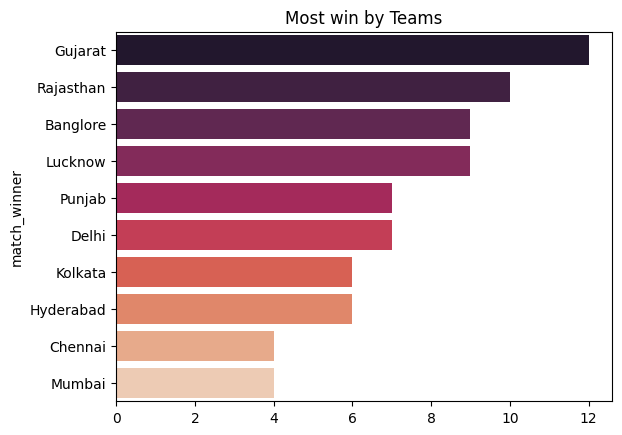

In [19]:
sns.barplot(x=match_wins.values, y=match_wins.index,palette='rocket')
plt.title('Most win by Teams')

Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends ')

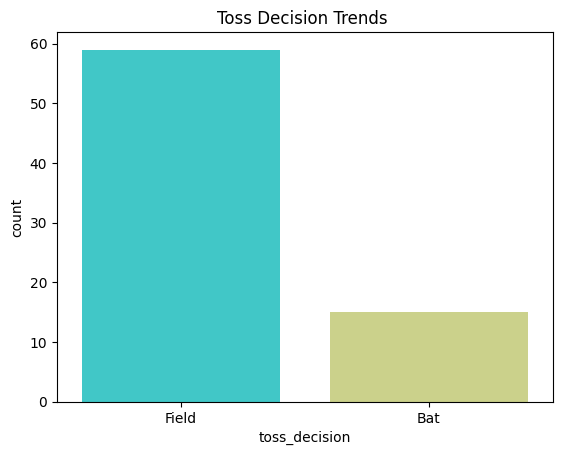

In [20]:
sns.countplot(x = df['toss_decision'],palette='rainbow')
plt.title("Toss Decision Trends ")

Toss Winner Vs Match Winner

In [27]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

How do teams win? (Run/Wicket)

Text(0.5, 1.0, 'Won by')

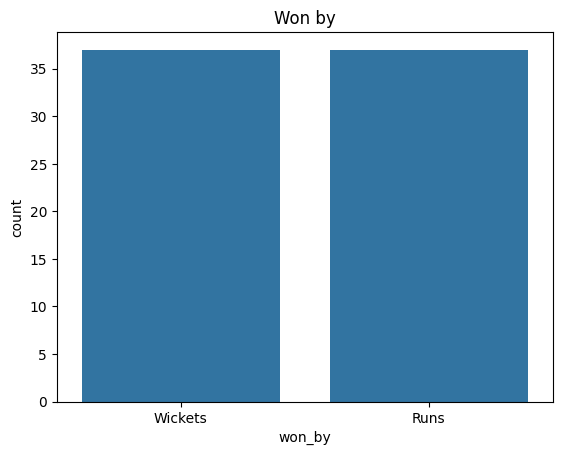

In [28]:
sns.countplot(x = df['won_by'])
plt.title("Won by")


**Key Player Performances **

Most POTM Awards

In [30]:
count = df['player_of_the_match'].value_counts().head(5)
count


,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2


Text(0.5, 1.0, 'Most Player of the Match Awards')

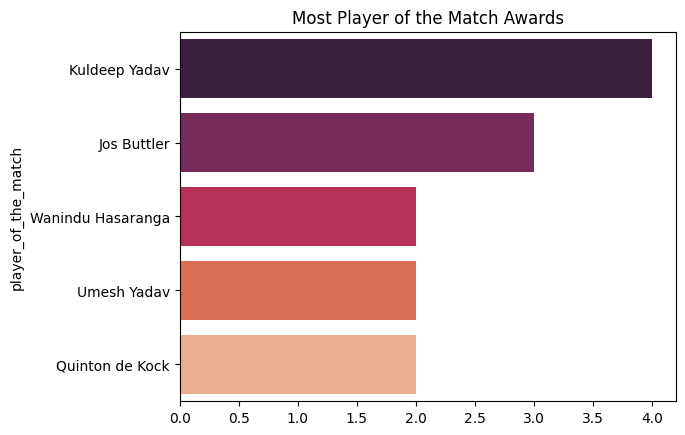

In [34]:
sns.barplot(x=count.values,y=count.index,palette='rocket')
plt.title("Most Player of the Match Awards")

Top Scorers

In [35]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

,highscore
top_scorer,
Jos Buttler,651
Quinton de Kock,377


Text(0.5, 1.0, 'Top Scorers')

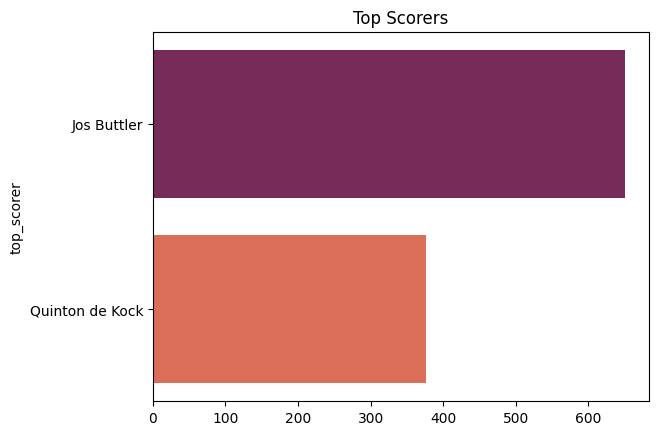

In [36]:
sns.barplot(x=high.values,y=high.index,palette='rocket')
plt.title("Top Scorers")


Best Bowling Figures

<Axes: ylabel='best_bowling'>

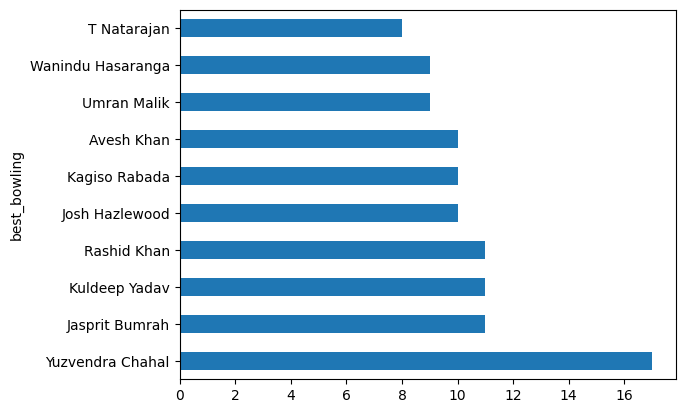

In [37]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

**Venue Analysis**

Most Matches Played by Venue

In [39]:
venue_count = df['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

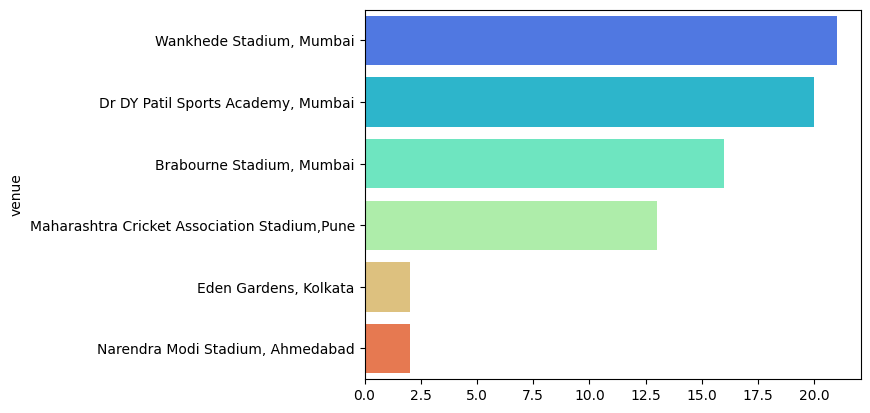

In [40]:
sns.barplot(y = venue_count.index,x = venue_count.values,palette='rainbow')

**Custom Questions and insights**

Who won the highest margin by runs?

In [41]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Which player had the highest individual score?

In [42]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which bowler had the best bowling figures?


In [43]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
